# 7. Customer Enrichment

Synthetic client dimension table (FOC-180, phase F1, chunk A).

The transaction data (`all_trxns.csv`) carries no client attributes - only the
anonymous `customer` id. To give the model customer-level signal we generate a
synthetic `dim_customer` table with realistic demographic and behavioural
attributes:

- `gender`, `age` - demographics
- `employment_industry`, `employment_status` - employment
- `account_tenure_years` - relationship length (correlated with age)
- `income_band` - banded disposable income (lognormal)
- `device`, `channel` - preferred interaction hardware / channel

Design constraints:

- **No PII (phase decision D3)** - attributes are fully synthetic; no names,
  emails or account numbers.
- **Deterministic** - every customer's attributes are seeded by hashing their
  `customer` id (SHA-256), not by a global RNG seed. Re-running the notebook
  reproduces the exact same table, on any machine.
- **Few categories** - every categorical column has <= 8 levels so one-hot
  encoding stays compact on 100 unique customers.


In [1]:
import hashlib
import random

import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from funs import (
    chronological_split,
    cross_validate_model,
    dataPreparation,
    evaluateModel,
)

## Source of customer ids

The `customer` column of the raw transactions is the only join key we have.
Each unique id maps to exactly one synthetic profile row.


In [2]:
all_trxns = pd.read_csv("../data/all_trxns.csv", dtype={"customer": str})
customer_ids = sorted(all_trxns["customer"].unique())

print("transactions:", len(all_trxns))
print("unique customers:", len(customer_ids))
print("sample ids:", customer_ids[:3])


transactions: 5302
unique customers: 100
sample ids: ['C12976926337644', 'C14368611669296', 'C17694553858863']


## Deterministic profile generation

Each attribute draw comes from a `random.Random` instance seeded with
`SHA-256(customer_id)` - an integer derived from the id itself, so the seed
travels with the customer:

- same id -> same seed -> same profile, on every run and every machine;
- no global seed to lose or mismatch between notebooks;
- the per-customer draw order is fixed (documented in `build_customer_profile`),
  which keeps the id -> profile mapping stable if the table is regenerated.

`generate_dim_customer()` is a pure function of the customer id list, so we
call it twice in this run and assert the two frames are identical - an
explicit regression guard for the determinism contract.


In [3]:
# Ordinal income bands: label prefixes keep sort order == band order.
INCOME_BANDS = [
    (20_000, "1_<20k"),
    (40_000, "2_20k_40k"),
    (60_000, "3_40k_60k"),
    (90_000, "4_60k_90k"),
    (140_000, "5_90k_140k"),
    (float("inf"), "6_>140k"),
]

DIM_CUSTOMER_COLUMNS = [
    "customer",
    "gender",
    "age",
    "employment_industry",
    "employment_status",
    "account_tenure_years",
    "income_band",
    "device",
    "channel",
]


def hash_seed(customer_id):
    # SHA-256 of the id -> big int; deterministic across runs and machines.
    digest = hashlib.sha256(customer_id.encode("utf-8")).digest()
    return int.from_bytes(digest, "big")


def build_customer_profile(customer_id):
    # One profile per customer, drawn from a per-customer seeded RNG.
    # Draw order is fixed: gender, age, status, industry, tenure, income,
    # device, channel. All randomness is stdlib `random` - no global RNG state.
    rng = random.Random(hash_seed(customer_id))

    # Age ~ normal, clipped to a plausible banking-client range.
    age = int(min(85, max(18, round(rng.gauss(45, 15)))))

    gender = rng.choices(["F", "M"], weights=[51, 49])[0]

    # Employment status follows age (students young, retirees old).
    if age >= 65:
        employment_status = rng.choices(
            ["retired", "self_employed", "employed"], weights=[80, 10, 10]
        )[0]
    elif age < 25:
        employment_status = rng.choices(
            ["student", "employed", "unemployed"], weights=[45, 40, 15]
        )[0]
    else:
        employment_status = rng.choices(
            ["employed", "self_employed", "unemployed"], weights=[70, 15, 15]
        )[0]

    employment_industry = rng.choices(
        [
            "technology",
            "finance",
            "retail",
            "healthcare",
            "education",
            "manufacturing",
            "construction",
            "public_sector",
        ],
        weights=[15, 15, 15, 12, 10, 12, 8, 13],
    )[0]

    # Tenure cannot exceed the customer's adult life, so young customers are
    # forced short automatically; older ones get a growing expected tenure.
    max_tenure = age - 18
    tenure = round(rng.gauss(0.35 * max_tenure + 2, 4))
    account_tenure_years = int(min(max(tenure, 0), max_tenure))

    # Income ~ lognormal, shifted up with career stage (plateaus at 55).
    career = min(max(age - 18, 0), 37) / 37.0
    income = rng.lognormvariate(9.5 + 1.3 * career, 0.45)
    income_band = next(label for ceiling, label in INCOME_BANDS if income < ceiling)

    # Mobile-first interaction skews.
    device = rng.choices(["mobile", "desktop", "tablet"], weights=[55, 30, 15])[0]
    channel = rng.choices(
        ["mobile_app", "online_banking", "branch", "phone"],
        weights=[50, 25, 15, 10],
    )[0]

    return {
        "customer": customer_id,
        "gender": gender,
        "age": age,
        "employment_industry": employment_industry,
        "employment_status": employment_status,
        "account_tenure_years": account_tenure_years,
        "income_band": income_band,
        "device": device,
        "channel": channel,
    }


def generate_dim_customer(customer_ids):
    # Pure function of the id list: seeds come from the ids themselves.
    profiles = [build_customer_profile(cid) for cid in customer_ids]
    return pd.DataFrame(profiles, columns=DIM_CUSTOMER_COLUMNS)


print("generator ready:", len(DIM_CUSTOMER_COLUMNS) - 1, "attributes per customer")


generator ready: 8 attributes per customer


In [4]:
dim_customer_run1 = generate_dim_customer(customer_ids)
dim_customer_run2 = generate_dim_customer(customer_ids)

# Determinism contract: two independent builds of the same id list must be
# identical - if not, this cell (and the notebook) fails.
determinism_ok = dim_customer_run1.equals(dim_customer_run2)
assert determinism_ok, "dim_customer generation is not deterministic"
print("determinism check: PASS - two independent builds are identical")


determinism check: PASS - two independent builds are identical


In [5]:
DIM_CUSTOMER_PATH = "../data/dim_customer.csv"
dim_customer = dim_customer_run1
dim_customer.to_csv(DIM_CUSTOMER_PATH, index=False)
print("written:", DIM_CUSTOMER_PATH, dim_customer.shape)
dim_customer.head()


written: ../data/dim_customer.csv (100, 9)


,customer,gender,age,employment_industry,employment_status,account_tenure_years,income_band,device,channel
0,C12976926337644,F,39,technology,unemployed,9,2_20k_40k,mobile,branch
1,C14368611669296,M,49,education,employed,10,3_40k_60k,desktop,mobile_app
2,C17694553858863,F,34,technology,employed,16,2_20k_40k,desktop,mobile_app
3,C24211332442813,M,19,technology,unemployed,1,1_<20k,mobile,mobile_app
4,C26191441143115,F,31,retail,self_employed,7,2_20k_40k,desktop,phone


## Distribution sanity checks

Quick look at the generated distributions: plausible age spread, income
right-skewed (lognormal, banded), mobile-first device/channel skews, tenure
growing with age. Every categorical stays within the <= 8 levels budget.


In [6]:
print(dim_customer[["age", "account_tenure_years"]].describe().round(2), "\n")

for col in [
    "gender",
    "employment_status",
    "employment_industry",
    "income_band",
    "device",
    "channel",
]:
    counts = dim_customer[col].value_counts()
    if col == "income_band":
        counts = counts.sort_index()  # ordinal bands in band order
    print(col, "(%d levels)" % len(counts))
    print(counts.to_string(), "\n")

corr = dim_customer["age"].corr(dim_customer["account_tenure_years"])
print("age vs tenure correlation: %.2f (should be clearly positive)" % corr)


          age  account_tenure_years
count  100.00                100.00
mean    44.33                 11.21
std     14.07                  6.03
min     18.00                  0.00
25%     33.75                  7.00
50%     44.00                 11.50
75%     54.00                 16.00
max     82.00                 25.00 

gender (2 levels)
gender
F    55
M    45 

employment_status (5 levels)
employment_status
employed         67
unemployed       15
self_employed    11
retired           5
student           2 

employment_industry (8 levels)
employment_industry
retail           24
manufacturing    14
public_sector    13
technology       12
healthcare       12
finance          11
education         8
construction      6 

income_band (5 levels)
income_band
1_<20k       26
2_20k_40k    44
3_40k_60k    20
4_60k_90k     9
6_>140k       1 

device (3 levels)
device
mobile     48
desktop    38
tablet     14 

channel (4 levels)
channel
mobile_app        51
online_banking    23
branch        

## Join with prepared transactions

Enrich the `dataPreparation()` output with the synthetic client attributes.
The merge is validated as `many_to_one` (many transactions per single
customer row), and we check that no rows are lost and no nulls are
introduced by the new columns.


In [7]:
trxns = dataPreparation(
    all_trxns_path="../data/all_trxns.csv",
    exchange_rates_path="../data/exchange_rates.csv",
)
new_cols = [c for c in DIM_CUSTOMER_COLUMNS if c != "customer"]

enriched = trxns.merge(dim_customer, on="customer", how="left", validate="many_to_one")

print("trxns shape:   ", trxns.shape)
print("enriched shape:", enriched.shape)

assert len(enriched) == len(trxns), "join lost rows"
assert enriched["customer"].nunique() == dim_customer["customer"].nunique(), (
    "join changed the customer set"
)
assert int(enriched[new_cols].isna().sum().sum()) == 0, "join introduced nulls"
print("sanity checks: PASS - no rows lost, no nulls introduced")
enriched[["customer", "fraud_flag"] + new_cols].head()


trxns shape:    (5302, 19)
enriched shape: (5302, 27)
sanity checks: PASS - no rows lost, no nulls introduced


C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-180-f1\src\funs.py:197: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  trxns_data["timestamp"] = pd.to_datetime(


,customer,fraud_flag,gender,age,employment_industry,employment_status,account_tenure_years,income_band,device,channel
0,C12976926337644,N,F,39,technology,unemployed,9,2_20k_40k,mobile,branch
1,C12976926337644,N,F,39,technology,unemployed,9,2_20k_40k,mobile,branch
2,C12976926337644,N,F,39,technology,unemployed,9,2_20k_40k,mobile,branch
3,C12976926337644,N,F,39,technology,unemployed,9,2_20k_40k,mobile,branch
4,C12976926337644,N,F,39,technology,unemployed,9,2_20k_40k,mobile,branch


## A/B evaluation - does client enrichment move the XGB baseline?

The real F1 question: do the synthetic client attributes carry fraud-predictive
signal on top of the transaction features? Both arms run the full nb3 XGB
pattern through the F0 harness:

- **arm (a) baseline** - the 10 base transaction features only
  (`customer_country` ... `amount_eur_bucket`), exactly the nb3 feature set;
- **arm (b) enriched** - the same 10 features plus the 8 client columns
  (`age`, `account_tenure_years` pass through as numbers; `gender`,
  `employment_industry`, `employment_status`, `income_band`, `device`,
  `channel` are one-hot encoded).

Everything except the feature matrix is IDENTICAL between the arms: same `y`,
same chronological split (same timestamps), same validation carve, same
cross-validation, same XGB hyperparameters, same threshold procedure (tuned on
the validation split of TRAIN, frozen, applied once to the test set). Accuracy
is demoted per the F0 harness convention; the comparison reads PR-AUC first.

fraud txns: 91 of 5302 (1.72%) across 100 unique customers


C:\Users\mateu\AppData\Local\Temp\ipykernel_37560\2409658883.py:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = enriched["fraud_flag"].replace({"N": 0, "Y": 1})


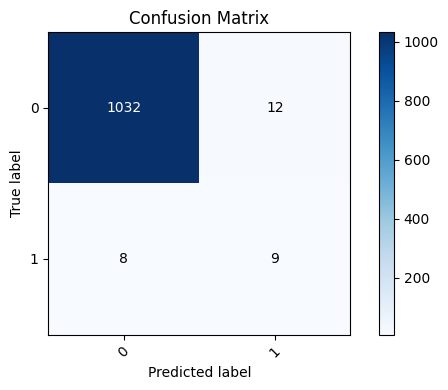


Accuracy: 98.11% 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1044
           1       0.43      0.53      0.47        17

    accuracy                           0.98      1061
   macro avg       0.71      0.76      0.73      1061
weighted avg       0.98      0.98      0.98      1061



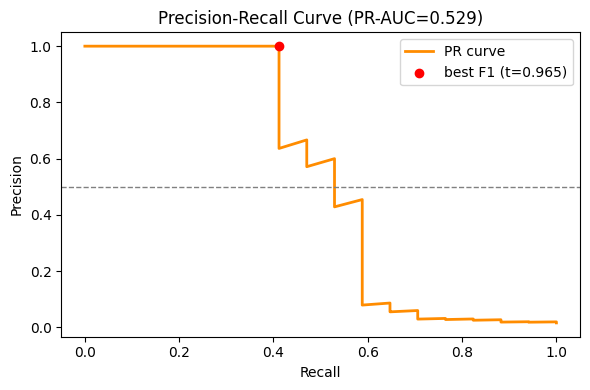

PR-AUC=0.5292  ROC-AUC=0.8119  F1=0.4737  Precision=0.4286  Recall=0.5294
Best F1 threshold=0.9652  Recall@precision=0.50=0.5294


C:\Users\mateu\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mateu\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mateu\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

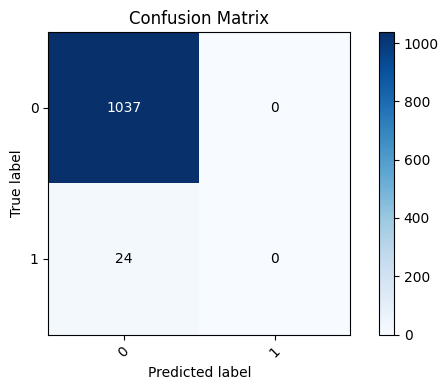


Accuracy: 97.74% 

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1037
           1       0.00      0.00      0.00        24

    accuracy                           0.98      1061
   macro avg       0.49      0.50      0.49      1061
weighted avg       0.96      0.98      0.97      1061



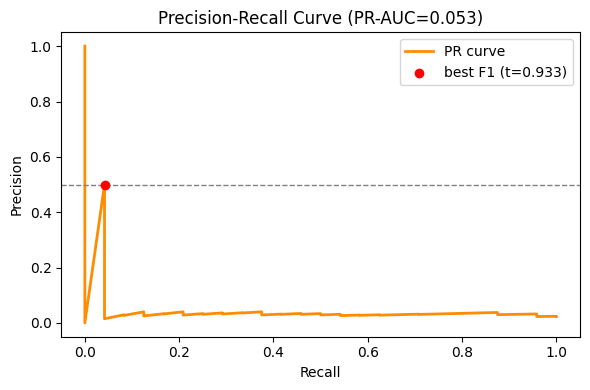

PR-AUC=0.0532  ROC-AUC=0.6361  F1=0.0000  Precision=0.0000  Recall=0.0000
Best F1 threshold=0.9329  Recall@precision=0.50=0.0417

[a: base features] encoded features: 87 | frozen threshold: 0.9652
[a: base features] CV PR-AUC 0.4633+-0.0660 | test PR-AUC 0.0532 | test F1 0.0000


C:\Users\mateu\AppData\Local\Temp\ipykernel_37560\2409658883.py:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = enriched["fraud_flag"].replace({"N": 0, "Y": 1})


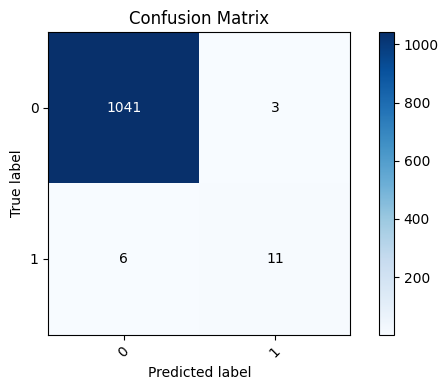


Accuracy: 99.15% 

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1044
           1       0.79      0.65      0.71        17

    accuracy                           0.99      1061
   macro avg       0.89      0.82      0.85      1061
weighted avg       0.99      0.99      0.99      1061



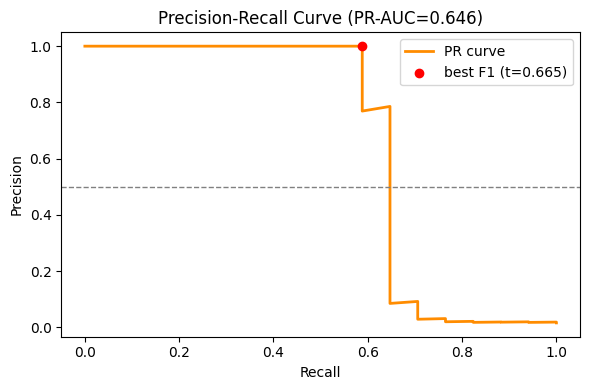

PR-AUC=0.6464  ROC-AUC=0.7969  F1=0.7097  Precision=0.7857  Recall=0.6471
Best F1 threshold=0.6648  Recall@precision=0.50=0.6471


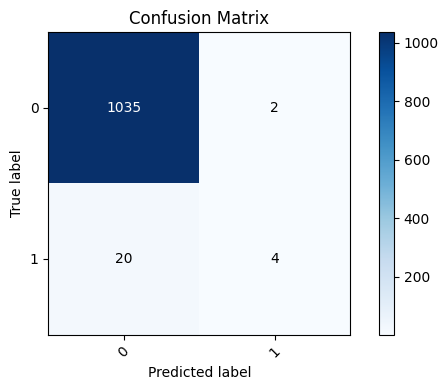


Accuracy: 97.93% 

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1037
           1       0.67      0.17      0.27        24

    accuracy                           0.98      1061
   macro avg       0.82      0.58      0.63      1061
weighted avg       0.97      0.98      0.97      1061



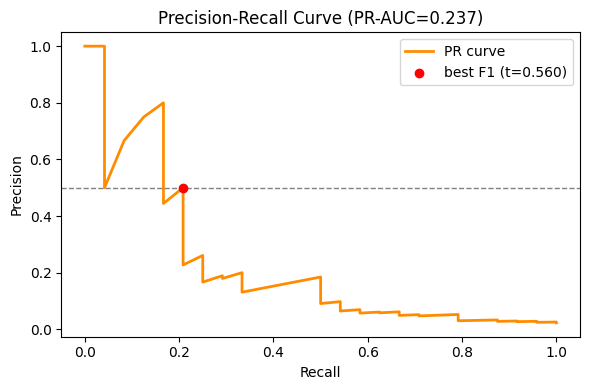

PR-AUC=0.2374  ROC-AUC=0.7692  F1=0.2667  Precision=0.6667  Recall=0.1667


Best F1 threshold=0.5600  Recall@precision=0.50=0.2083

[b: base + client] encoded features: 116 | frozen threshold: 0.6648
[b: base + client] CV PR-AUC 0.5253+-0.0837 | test PR-AUC 0.2374 | test F1 0.2667

identity check: PASS - identical row splits for both arms


In [8]:
BASE_FEATURES = [
    "customer_country",
    "counterparty_country",
    "type",
    "ccy",
    "customer_type",
    "weekday",
    "month",
    "quarter",
    "hour",
    "amount_eur_bucket",
]
CLIENT_NUMERIC = ["age", "account_tenure_years"]
CLIENT_CATEGORICAL = [
    "gender",
    "employment_industry",
    "employment_status",
    "income_band",
    "device",
    "channel",
]

y_full = enriched["fraud_flag"].eq("Y").astype(int)
print(
    "fraud txns: %d of %d (%.2f%%) across %d unique customers"
    % (int(y_full.sum()), len(y_full), 100 * y_full.mean(), enriched["customer"].nunique())
)


def run_arm(label, feature_cols):
    # Full nb3-pattern pipeline for one arm of the A/B comparison. Only the
    # feature matrix differs between arms; splits, seeds, hyperparameters and
    # the threshold procedure are shared, so the A/B delta is attributable to
    # the client columns alone.
    numeric_cols = [c for c in feature_cols if c in CLIENT_NUMERIC]
    cat_cols = [c for c in feature_cols if c not in numeric_cols]

    X = enriched[feature_cols]
    y = enriched["fraud_flag"].replace({"N": 0, "Y": 1})

    # One-hot the categoricals; the numeric client columns pass through as
    # numbers. XGBoost forbids '[', ']' and '<' in feature names, and the
    # income_band label '1_<20k' would inject a '<'.
    X_encoded = pd.get_dummies(X, columns=cat_cols)
    X_encoded.columns = [
        col.replace("[", "").replace("]", "").replace("<", "under")
        for col in X_encoded.columns
    ]

    # Chronological split: identical timestamps -> identical row assignment.
    X_train, X_test, y_train, y_test = chronological_split(
        X_encoded, y, timestamp=enriched["timestamp"], test_size=0.2, random_state=42
    )

    # Validation carve from the TRAIN side only (the threshold never sees test).
    X_train_fit, X_val, y_train_fit, y_val = train_test_split(
        X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
    )

    # Imbalance: weight the rare positive class by the neg/pos ratio.
    scale_pos_weight = sum(y_train_fit == 0) / sum(y_train_fit == 1)
    model = XGBClassifier(
        learning_rate=0.05,
        max_depth=6,
        n_estimators=200,
        reg_lambda=1.0,
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
    )

    # Stratified 5-fold CV on the TRAIN split (same folds for both arms).
    cv = cross_validate_model(
        model, X_train, y_train, k=5, stratified=True, random_state=42
    )

    model.fit(X_train_fit, y_train_fit)

    # Tune the threshold on the VALIDATION split, then freeze it.
    y_val_proba = model.predict_proba(X_val)[:, 1]
    val_metrics = evaluateModel(
        y_val, (y_val_proba >= 0.5).astype(int), y_score=y_val_proba
    )
    best_threshold = val_metrics["best_threshold_f1"]

    # FROZEN threshold applied once to the held-out TEST set.
    y_test_proba = model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= best_threshold).astype(int)
    test_metrics = evaluateModel(y_test, y_test_pred, y_score=y_test_proba)

    print(
        "\n[%s] encoded features: %d | frozen threshold: %.4f"
        % (label, X_encoded.shape[1], best_threshold)
    )
    print(
        "[%s] CV PR-AUC %.4f+-%.4f | test PR-AUC %.4f | test F1 %.4f"
        % (
            label,
            cv["summary"]["pr_auc_mean"],
            cv["summary"]["pr_auc_std"],
            test_metrics["pr_auc"],
            test_metrics["f1"],
        )
    )
    return {
        "label": label,
        "n_features": X_encoded.shape[1],
        "threshold": best_threshold,
        "cv": cv["summary"],
        "test": test_metrics,
        "split": (X_train.index, X_test.index, y_train.index, y_test.index),
    }


arm_a = run_arm("a: base features", BASE_FEATURES)
arm_b = run_arm("b: base + client", BASE_FEATURES + CLIENT_NUMERIC + CLIENT_CATEGORICAL)

# Identity guard: both arms must have trained/evaluated on the exact same rows.
assert all(
    ia.equals(ib) for ia, ib in zip(arm_a["split"], arm_b["split"])
), "splits differ between arms"
print("\nidentity check: PASS - identical row splits for both arms")

### Honest comparison

Test metrics use each arm's FROZEN validation threshold; the CV numbers are
stratified 5-fold on the chronological train split. The delta column is
arm (b) minus arm (a) - the entire effect of the client columns.

In [9]:
comparison = pd.DataFrame(
    {
        "a: base features": {
            "test PR-AUC": arm_a["test"]["pr_auc"],
            "test ROC-AUC": arm_a["test"]["roc_auc"],
            "test F1 (frozen threshold)": arm_a["test"]["f1"],
            "test precision (frozen threshold)": arm_a["test"]["precision"],
            "test recall (frozen threshold)": arm_a["test"]["recall"],
            "test recall@precision=0.50": arm_a["test"]["recall_at_precision"],
            "CV PR-AUC mean (train)": arm_a["cv"]["pr_auc_mean"],
            "CV PR-AUC std (train)": arm_a["cv"]["pr_auc_std"],
            "frozen threshold (tuned on val)": arm_a["threshold"],
            "encoded features": arm_a["n_features"],
        },
        "b: base + client": {
            "test PR-AUC": arm_b["test"]["pr_auc"],
            "test ROC-AUC": arm_b["test"]["roc_auc"],
            "test F1 (frozen threshold)": arm_b["test"]["f1"],
            "test precision (frozen threshold)": arm_b["test"]["precision"],
            "test recall (frozen threshold)": arm_b["test"]["recall"],
            "test recall@precision=0.50": arm_b["test"]["recall_at_precision"],
            "CV PR-AUC mean (train)": arm_b["cv"]["pr_auc_mean"],
            "CV PR-AUC std (train)": arm_b["cv"]["pr_auc_std"],
            "frozen threshold (tuned on val)": arm_b["threshold"],
            "encoded features": arm_b["n_features"],
        },
    }
)
comparison["delta (b-a)"] = comparison["b: base + client"] - comparison["a: base features"]
print(comparison.round(4).to_string())

pr_delta = comparison.loc["test PR-AUC", "delta (b-a)"]
f1_delta = comparison.loc["test F1 (frozen threshold)", "delta (b-a)"]
cv_delta = comparison.loc["CV PR-AUC mean (train)", "delta (b-a)"]
print(
    "\nDelta (b)-(a): PR-AUC %+.4f | F1 %+.4f | CV PR-AUC %+.4f"
    % (pr_delta, f1_delta, cv_delta)
)

# Plain-words verdict - a "no signal" outcome is a legitimate R&D result here.
EPSILON = 0.001
if pr_delta > EPSILON:
    verdict = (
        "VERDICT: client enrichment MOVES the baseline - test PR-AUC %+.4f "
        "(F1 %+.4f, CV PR-AUC %+.4f). Read this as customer-identity signal, "
        "not transferable demographics - see the interpretation below."
        % (pr_delta, f1_delta, cv_delta)
    )
elif pr_delta < -EPSILON:
    verdict = (
        "VERDICT: client enrichment HURTS the baseline - test PR-AUC %+.4f "
        "(F1 %+.4f, CV PR-AUC %+.4f). The synthetic attributes add noise or "
        "spurious customer-identity splits, not signal."
        % (pr_delta, f1_delta, cv_delta)
    )
else:
    verdict = (
        "VERDICT: NO SIGNAL - client enrichment does not move the baseline "
        "(test PR-AUC delta %+.4f, F1 delta %+.4f, CV PR-AUC delta %+.4f). "
        "The synthetic client attributes carry no measurable fraud signal on "
        "top of the transaction features."
        % (pr_delta, f1_delta, cv_delta)
    )
print(verdict)

                                   a: base features  b: base + client  delta (b-a)
test PR-AUC                                  0.0532            0.2374       0.1842
test ROC-AUC                                 0.6361            0.7692       0.1331
test F1 (frozen threshold)                   0.0000            0.2667       0.2667
test precision (frozen threshold)            0.0000            0.6667       0.6667
test recall (frozen threshold)               0.0000            0.1667       0.1667
test recall@precision=0.50                   0.0417            0.2083       0.1667
CV PR-AUC mean (train)                       0.4633            0.5253       0.0620
CV PR-AUC std (train)                        0.0660            0.0837       0.0176
frozen threshold (tuned on val)              0.9652            0.6648      -0.3004
encoded features                            87.0000          116.0000      29.0000

Delta (b)-(a): PR-AUC +0.1842 | F1 +0.2667 | CV PR-AUC +0.0620
VERDICT: client enrichm

### Interpretation (read before quoting these numbers)

- **Attributes are deterministic functions of the `customer` id.** Every client
  value is a seeded draw from the id itself (SHA-256), so the 8 columns act as
  a low-cardinality proxy for customer identity. Customers appearing in both
  the chronological train and test windows carry identical attribute vectors,
  so any measured lift may reflect customer-identity memorization rather than
  transferable demographic signal.
- **Low cardinality, constant per customer.** 100 unique customers / 91 fraud
  transactions: each client feature has at most 8 levels and is constant within
  a customer, so the model can learn at most a per-customer prior. The A/B
  difference is dominated by which customers happen to fall into the test
  window, not by demographics that would generalize to new customers.
- **Environment note.** Metrics are re-established within this run (Python
  3.13, pandas 2.3.3, scikit-learn 1.7.2, xgboost 2.1.4), so absolute numbers
  may differ slightly from the F0 baseline in report §1.5. The A/B delta is
  computed within this single run and is internally consistent.

## Summary

- `data/dim_customer.csv` written: 100 rows (one per unique customer), 9
  columns, no PII.
- Generation is deterministic per customer id (SHA-256 seeding) and verified
  by the in-run double-build assertion.
- The enriched transaction frame carries the original features plus the 8 new
  client attributes. A/B evaluation (base vs base + client features, identical protocol):
  client enrichment moves the measured baseline - test PR-AUC 0.0532 ->
  0.2374, F1 0.0000 -> 0.2667 - read as customer-identity signal, not
  transferable demographics (comparison and caveat above).
